In [6]:
import geopandas as gpd

# python -m ipykernel install --user --name geo-sylv --display-name "Python (geo-sylv)"

project = gpd.read_file("data/projects/project_001/geometry.geojson")
project = project.to_crs(epsg=2154)
area_ha = project.geometry.area / 10000
print(area_ha)

0    12584.534459
dtype: float64


<Axes: >

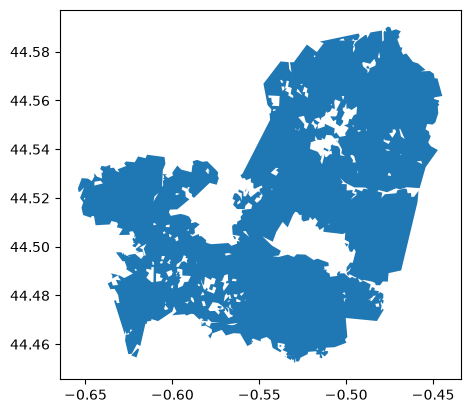

In [2]:
project.plot()

In [ ]:
geom = project.geometry.iloc[0]
print(type(geom))
print(len(geom.geoms))

<class 'shapely.geometry.multipolygon.MultiPolygon'>
14


In [9]:
for i, poly in enumerate(geom.geoms):
    print(i, poly.area / 10_000, "ha")

0 6.718663217618495 ha
1 0.5401013308506942 ha
2 1.738416145056767 ha
3 3.286571338156663 ha
4 1.0523096987092508 ha
5 12565.991068054645 ha
6 0.3276062091027232 ha
7 0.09547986900780481 ha
8 1.233238152405567 ha
9 1.9801274209537776 ha
10 0.04204808057373602 ha
11 0.2547249141633215 ha
12 1.2334008163198036 ha
13 0.04070412202881263 ha


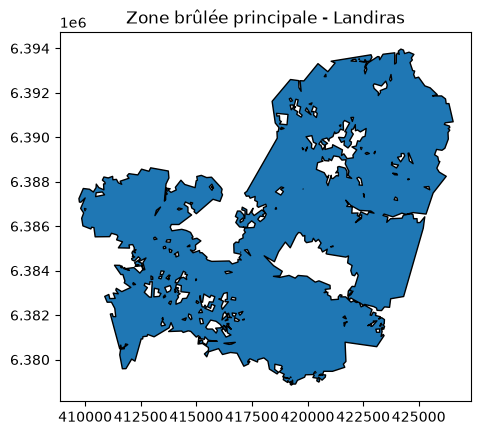

In [10]:
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

# on récupère le polygone principal (celui avec l'aire max)
main_poly = geom.geoms[5]

gpd.GeoSeries([main_poly], crs="EPSG:2154").plot(edgecolor="black")
plt.title("Zone brûlée principale - Landiras")
plt.show()

In [12]:
print("Nombre de trous (interiors) :", len(main_poly.interiors))

# surface totale des trous
from shapely.geometry import Polygon

holes_area = sum(Polygon(ring).area for ring in main_poly.interiors) / 10_000
print("Surface totale des trous :", holes_area, "ha")

main_poly_filled = Polygon(main_poly.exterior)

print("Aire remplie (sans trous) :", main_poly_filled.area / 10_000, "ha")
print("Aire originale (avec trous) :", main_poly.area / 10_000, "ha")

Nombre de trous (interiors) : 101
Surface totale des trous : 1103.228969212549 ha
Aire remplie (sans trous) : 13669.2200372672 ha
Aire originale (avec trous) : 12565.991068054645 ha


In [13]:
# on isole le trou principal (le plus grand)
hole_areas = [Polygon(ring).area for ring in main_poly.interiors]
main_hole = Polygon(main_poly.interiors[hole_areas.index(max(hole_areas))])

print("Aire du trou principal :", main_hole.area / 10_000, "ha")

# centroïde en Lambert-93, puis reprojeté en lat/lon pour le lire facilement
centroid_lambert = gpd.GeoSeries([main_hole.centroid], crs="EPSG:2154")
centroid_wgs84 = centroid_lambert.to_crs(epsg=4326)
print("Centroïde (lat/lon) :", centroid_wgs84.iloc[0].y, centroid_wgs84.iloc[0].x)

Aire du trou principal : 572.1136629826552 ha
Centroïde (lat/lon) : 44.50092238805289 -0.5184626640062155


In [14]:
lat, lon = centroid_wgs84.iloc[0].y, centroid_wgs84.iloc[0].x
print(f"Google Maps : https://www.google.com/maps?q={lat},{lon}")
print(f"OpenStreetMap : https://www.openstreetmap.org/?mlat={lat}&mlon={lon}&zoom=15")

Google Maps : https://www.google.com/maps?q=44.50092238805289,-0.5184626640062155
OpenStreetMap : https://www.openstreetmap.org/?mlat=44.50092238805289&mlon=-0.5184626640062155&zoom=15


In [15]:
import os

clean_gdf = gpd.GeoDataFrame(geometry=[main_poly], crs="EPSG:2154").to_crs(epsg=4326)

out_dir = "data/projects/project_001"
os.makedirs(out_dir, exist_ok=True)
clean_gdf.to_file(os.path.join(out_dir, "geometry_clean.geojson"), driver="GeoJSON")

print("Sauvegardé :", os.path.join(out_dir, "geometry_clean.geojson"))
print("Nouvelle surface :", clean_gdf.to_crs(epsg=2154).geometry.area.sum() / 10_000, "ha")

Sauvegardé : data/projects/project_001\geometry_clean.geojson
Nouvelle surface : 12565.99106805479 ha
